## Project 2 - Hospital utilization

In [275]:
import numpy as np

np.random.seed(10) 

# length of epidemic i.e. length of simulation
T = 365
# time vector
t = np.arange(0, T, 1) # start, stop, step

# Functions for arrival times for ward A, B and C
def rate_A(t):
    rate = -(1/3650)*t**2 + (1/10)*t
    return rate

def rate_B(t):
    rate = (1/5) * rate_A(t)
    return rate

def rate_C(t):
    rate = 6
    return rate

# rate vectors as a function of time
rates_A = rate_A(t)
rates_B = rate_B(t)

# max rates for ward A and B
max_rate_A = np.max(rates_A) + 0.2
max_rate_B = np.max(rates_B) + 0.2

print("Max rate for ward A:", max_rate_A)
print("Max rate for ward B:", max_rate_B)

#print(rates_A)
print(np.random.exponential(1/max_rate_A, size=10))


Max rate for ward A: 9.324931506849316
Max rate for ward B: 2.0249863013698635
[0.1582247  0.00224884 0.10768565 0.14815351 0.07401295 0.02730636
 0.02367042 0.15328049 0.01986705 0.00991835]


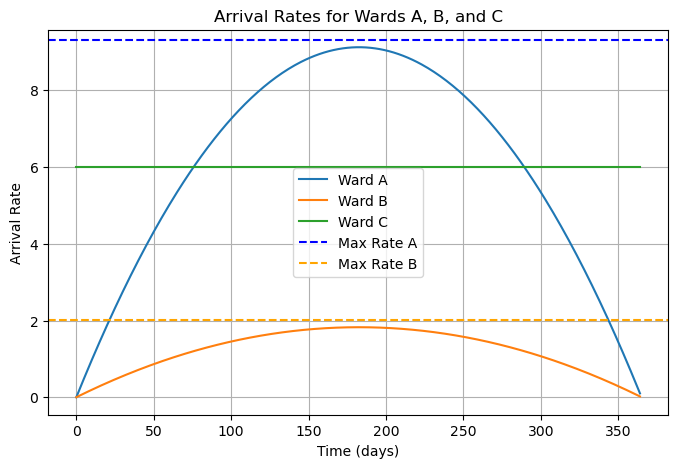

In [276]:
# Plot of arrival rates
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(t, [-(1/3650)*time**2 + (1/10)*time for time in t], label='Ward A')
plt.plot(t, [(1/5) * (-(1/3650)*time**2 + (1/10)*time) for time in t], label='Ward B')
plt.plot(t, [6 for time in t], label='Ward C')
plt.axhline(y=max_rate_A, color='blue', linestyle='--', label='Max Rate A')
plt.axhline(y=max_rate_B, color='orange', linestyle='--', label='Max Rate B')
plt.xlabel('Time (days)')
plt.ylabel('Arrival Rate')
plt.title('Arrival Rates for Wards A, B, and C')
plt.legend()
plt.grid()
plt.show()

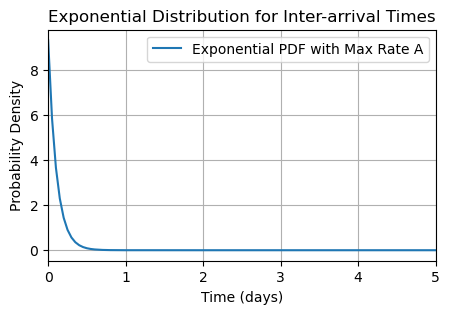

In [277]:
# Plot of exponential distribution with max rates to see what we are sampling from for inter-arrival times
import scipy.stats as stats

t = np.linspace(0, 50, 1000)  # time vector for PDF plot
pdf = stats.expon.pdf(t, scale=1/max_rate_A)  # PDF of exponential distribution with max rate A

plt.figure(figsize=(5, 3))
plt.plot(t, pdf, label='Exponential PDF with Max Rate A')
plt.xlabel('Time (days)')
plt.ylabel('Probability Density')
plt.title('Exponential Distribution for Inter-arrival Times')
plt.legend()
plt.xlim(0, 5)
plt.grid()
plt.show()


In [278]:
# Simulation of arrival times for each ward for 365 days

np.random.seed(10) 


# Drawing with an "artificially" large rate to ensure we get enough events, then we will filter them based on the actual rate function

def generate_arrival_and_los_times(los_dist):

    # ARRIVAL TIMES 

    # Lists to store cumulated arrival times for each ward
    events_A = []
    events_B = []
    events_C = []

    ###### WARD A ######
    t = 0
    while t < T:
        t += np.random.exponential(1/max_rate_A) 
        if t < T:
            events_A.append(t)
    ###### WARD B ######
    t = 0
    while t < T:
        t += np.random.exponential(1/max_rate_B)
        if t < T:
            events_B.append(t)
    ###### WARD C ######
    t = 0
    while t < T:
        t += np.random.exponential(1/rate_C(t))
        if t < T:
            events_C.append(t)

    # Filter events for ward A and B based on the actual rate functions
    filtered_events_A = []
    filtered_events_B = []

    # Drawing from a uniform distribution from zero to max_rate to decide whether to keep the event based on the actual rate at that time
    for time in events_A:
        if np.random.uniform(0, max_rate_A) < rate_A(time):
            filtered_events_A.append(time)

    for time in events_B:
        if np.random.uniform(0, max_rate_B) < rate_B(time):
            filtered_events_B.append(time)
    '''
    print("Number of events generated for Ward A:", len(events_A))
    print("Number of events generated for Ward B:", len(events_B))

    print("\nNumber of arrivals in Ward A:", len(filtered_events_A))
    print("Number of arrivals in Ward B:", len(filtered_events_B))
    print("Number of arrivals in Ward C:", len(events_C))
    '''

    # creating event list for all wards
    events = []
    for time in filtered_events_A:
        events.append((time, 'A'))
    for time in filtered_events_B:
        events.append((time, 'B'))
    for time in events_C:
        events.append((time, 'C'))
    # sorting events by time
    events.sort(key=lambda x: x[0])

    # LOS TIMES
    mu_A = np.log(4*np.sqrt(2))
    sigma_A = np.sqrt(np.log(2))
    mu_B = np.log(6*np.sqrt(2))
    sigma_B = np.sqrt(np.log(2))
    mu_C = np.log(5*np.sqrt(2))
    sigma_C = np.sqrt(np.log(2))
    lamb_exp_A = 1/8
    lamb_exp_B = 1/12
    lamb_exp_C = 1/10

    # Generates LOS times for each ward. One LOS per arrival is generated. 
    if los_dist == 'lognormal':
        
        # Generate LOS times matching the sorted events
        patients = []

        for time, ward in events:
            if ward == 'A':
                los = np.random.lognormal(mean=mu_A, sigma=sigma_A)
            elif ward == 'B':
                los = np.random.lognormal(mean=mu_B, sigma=sigma_B)
            elif ward == 'C':
                los = np.random.lognormal(mean=mu_C, sigma=sigma_C)

            patients.append((time, ward, los))


    elif los_dist == 'exponential':
    
        patients = []

        for time, ward in events:
            if ward == 'A':
                los = np.random.exponential(scale=1/lamb_exp_A)
            elif ward == 'B':
                los = np.random.exponential(scale=1/lamb_exp_B)
            elif ward == 'C':
                los = np.random.exponential(scale=1/lamb_exp_C)

            patients.append((time, ward, los))


    return patients, filtered_events_A, filtered_events_B, events_C


In [279]:
patients, filtered_events_A, filtered_events_B, arrival_times_C =generate_arrival_and_los_times('lognormal')

print(filtered_events_A[:5])  # Print first 10 arrival times for Ward A
print(patients[:10])  # Print first 20 events (time and ward)
print(len(patients))  # Print total number of patients
# patients is a list of tuples containing arrival times, ward type and los time 

[2.6097830883285065, 4.312771817562885, 4.509919515886317, 7.695928192149847, 9.100100676110626]
[(0.536971472995665, 'C', 4.378935886885078), (0.5397227082741316, 'C', 1.869052287382891), (0.661142537766257, 'C', 20.725464009026528), (0.8161615452481548, 'C', 3.727650242938706), (0.9085618535764277, 'C', 3.758993661710188), (1.452981356689186, 'C', 5.965015894262448), (1.7224677105954187, 'C', 12.395880946117611), (1.9100558285799116, 'C', 26.033363641169707), (2.3112559158420125, 'C', 8.378404073373563), (2.4643122952203402, 'C', 10.597593497091438)]
4980


In [280]:
# Simulating flow of patients in and out of wards

np.random.seed(10) 

import heapq
from tqdm import tqdm


def simulate_hospital(beds_in_A, beds_in_B, patients, filtered_events_A, filtered_events_B, events_C):

    beds_in_C = 75 - (beds_in_A + beds_in_B)
    
    # Number of blocked patients for each ward
    blocked_A_to_out = 0
    transferred_B_to_A = 0
    blocked_A_from_B = 0
    blocked_C_to_out = 0
    blocked_B = 0
    # list that contains scheduled discharge times for each ward
    discharge_times_A = []
    discharge_times_B = []
    discharge_times_C = []
    # Total number of utilization hours for each ward
    los_A_total = 0
    los_B_total = 0
    los_C_total = 0

    # Each iteration represents one patient arriving at the hospital
    for t, ward, los in patients:

    ##################### Discharging patients before processing arrivals #####################
        # while discharge_times_A is not empty AND the earliest discharge time is <= current time:
        while discharge_times_A and discharge_times_A[0] <= t:
            # heapq.heappop removes and returns the smallest number of discharge times, i.e. the earliest departure time
            heapq.heappop(discharge_times_A)

        while discharge_times_B and discharge_times_B[0] <= t:
            heapq.heappop(discharge_times_B)

        while discharge_times_C and discharge_times_C[0] <= t:
            heapq.heappop(discharge_times_C)


        ##################### Processing arrivals #####################

        if ward == 'A':

            # if number of occupied beds are less than number of beds, patient gets a bed
            if len(discharge_times_A) < beds_in_A:
                # generate a discharge time for the patient based on an exponential distribution with mean 7 days
                los_A_total += los
                discharge_time = t + los
                # add the discharge time to the list of discharge times for ward A
                heapq.heappush(discharge_times_A, discharge_time) # heapq.heappush inserts discharge time while maintaining the order from smallest to largest

            else:
                blocked_A_to_out +=1 

        elif ward == 'B':
            if len(discharge_times_B) < beds_in_B:
                los_B_total += los
                discharge_time = t + los
                heapq.heappush(discharge_times_B, discharge_time)

            elif len(discharge_times_A) < beds_in_A:
                los_A_total += los
                discharge_time = t + los
                heapq.heappush(discharge_times_A, discharge_time)
                blocked_B += 1
                transferred_B_to_A +=1

            else:
                blocked_B += 1
                blocked_A_from_B +=1

        elif ward == 'C':
            if len(discharge_times_C) < beds_in_C:
                los_C_total += los
                discharge_time = t + los
                heapq.heappush(discharge_times_C, discharge_time)

            else:
                blocked_C_to_out +=1

    # Utilization metrics for each ward
    utilization_A = los_A_total / (beds_in_A * T) if beds_in_A > 0 else np.nan
    utilization_B = los_B_total / (beds_in_B * T) if beds_in_B > 0 else np.nan
    utilization_C = los_C_total / (beds_in_C * T) if beds_in_C > 0 else np.nan

    metrics = {
        "Number of arrivals in A": len(filtered_events_A),
        "Number of arrivals in B": len(filtered_events_B),
        "Number of arrivals in C": len(events_C),
        "Total number of arrivals": len(filtered_events_A) + len(filtered_events_B) + len(events_C),
        "Number of Blocked regular patients in A": blocked_A_to_out,
        "Number of Blocked intensive patients in B": blocked_B,
        "Number of Transferred intensive patients from B to A": transferred_B_to_A,
        "Number of Blocked intensive patients in A": blocked_A_from_B,
        "Number of Blocked inpatients in C": blocked_C_to_out,
        "Total number of relocated patients (also internally)": blocked_A_to_out + blocked_B + blocked_C_to_out,
        "Probability of a regular patient being blocked in A": blocked_A_to_out / len(filtered_events_A),
        "Probability of an intensive patient being blocked in A": blocked_A_from_B / len(filtered_events_B),
        "Probability of an intensive patient being blocked in B": (blocked_B) / len(filtered_events_B),
        "Probability of an inpatient patient being blocked in C": blocked_C_to_out / len(events_C),
        "Utilization of ward A": utilization_A,
        "Utilization of ward B": utilization_B,
        "Utilization of ward C": utilization_C
    }

    return metrics


In [ ]:
# More replications (keeping the arrival times fixed and rerunning, simulate hospital, i.e. LOSs )
n_replications = 100
results = []
for _ in tqdm(range(n_replications), desc="Running simulations"):
    # Re-run the simulation and store the results in a list
    patients, filtered_events_A, filtered_events_B, events_C = generate_arrival_and_los_times('lognormal')
    result = simulate_hospital(beds_in_A = 37, beds_in_B = 5, patients=patients, filtered_events_A=filtered_events_A, filtered_events_B=filtered_events_B, events_C=events_C)
    results.append(result)

#print("Metrics from the last simulation run:")
#print(results[99])

# Calculate average metrics across all replications
for i, key in enumerate(results[0].keys()):
    avg_value = np.mean([result[key] for result in results])
    std = np.std([result[key] for result in results], ddof=1)
    ci_low = avg_value - 1.96 * (std / np.sqrt(n_replications))
    ci_high = avg_value + 1.96 * (std / np.sqrt(n_replications))
    print(f"Average {key}: {avg_value:.3f}, Standard Deviation: {std:.2f},  95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

    if i in [3, 8, 9, 13]:
        print()

Running simulations: 100%|██████████| 100/100 [00:02<00:00, 48.11it/s]

Average Number of arrivals in A: 2212.840, Standard Deviation: 41.76,  95% CI: [2204.66, 2221.02]
Average Number of arrivals in B: 445.450, Standard Deviation: 21.06,  95% CI: [441.32, 449.58]
Average Number of arrivals in C: 2187.550, Standard Deviation: 47.70,  95% CI: [2178.20, 2196.90]
Average Total number of arrivals: 4845.840, Standard Deviation: 65.48,  95% CI: [4833.01, 4858.67]

Average Number of Blocked regular patients in A: 1013.990, Standard Deviation: 46.05,  95% CI: [1004.96, 1023.02]
Average Number of Blocked intensive patients in B: 313.410, Standard Deviation: 23.23,  95% CI: [308.86, 317.96]
Average Number of Transferred intensive patients from B to A: 157.040, Standard Deviation: 15.06,  95% CI: [154.09, 159.99]
Average Number of Blocked intensive patients in A: 156.370, Standard Deviation: 15.75,  95% CI: [153.28, 159.46]
Average Number of Blocked inpatients in C: 1006.140, Standard Deviation: 51.42,  95% CI: [996.06, 1016.22]

Average Total number of relocated pat

## Optimal bed distribution


In [284]:
import pandas as pd

np.random.seed(5)

N_rep = 1000  # Number of replications for each bed configuration

# Number of beds in A and B that I want to try
beds_A = np.arange(0, 76, 1)
beds_B = np.arange(0, 76, 1)

bed_results = []

for _ in tqdm(range(N_rep)):
    # Run with new arrival times and LOSs for each replication
    patients, filtered_events_A, filtered_events_B, events_C = generate_arrival_and_los_times('lognormal')

    for beds_in_A in beds_A:
        for beds_in_B in beds_B:

            if beds_in_A + beds_in_B <= 75:  

                beds_in_C = 75 - (beds_in_A + beds_in_B)

                if beds_in_A == 1 and beds_in_B == 1 and beds_in_C == 1:
                    print("Running simulation for beds in A:", beds_in_A, "beds in B:", beds_in_B, "beds in C:", beds_in_C)

                results = simulate_hospital(beds_in_A=beds_in_A, 
                                            beds_in_B=beds_in_B, 
                                            patients=patients, 
                                            filtered_events_A=filtered_events_A, 
                                            filtered_events_B=filtered_events_B, 
                                            events_C=events_C)

                bed_results.append({
                    "Beds in A": beds_in_A,
                    "Beds in B": beds_in_B,
                    "Beds in C": beds_in_C,
                    "Total number of relocated patients (also internally)": results["Total number of relocated patients (also internally)"],
                    "Probability of a regular patient being blocked in A": results["Probability of a regular patient being blocked in A"],
                    "Probability of an intensive patient being blocked in A": results["Probability of an intensive patient being blocked in A"],
                    "Probability of an intensive patient being blocked in B": results["Probability of an intensive patient being blocked in B"],
                    "Probability of an inpatient patient being blocked in C": results["Probability of an inpatient patient being blocked in C"],
                    "Utilization of ward A": results["Utilization of ward A"],
                    "Utilization of ward B": results["Utilization of ward B"],
                    "Utilization of ward C": results["Utilization of ward C"]
                })

    df = pd.DataFrame(bed_results)

# Results for same bed distribution are grouped and mean and std are calculated for each group.
summary = (
    df
    .groupby(["Beds in A", "Beds in B", "Beds in C"])
    .agg(
        mean_relocated=("Total number of relocated patients (also internally)", "mean"),
        std_relocated=("Total number of relocated patients (also internally)", "std"),
        mean_block_A=("Probability of a regular patient being blocked in A", "mean"),
        mean_block_B=("Probability of an intensive patient being blocked in B", "mean"),
        mean_block_C=("Probability of an inpatient patient being blocked in C", "mean"),
        mean_util_A=("Utilization of ward A", "mean"),
        mean_util_B=("Utilization of ward B", "mean"),
        mean_util_C=("Utilization of ward C", "mean")
    )
    .reset_index()
)

# finds the row with the lowest average number of relocated patients, i.e. the bed distribution that performed best on average over the N_rep replications. 
best = summary.loc[summary["mean_relocated"].idxmin()]
print("Minimum average number of relocated patients:", best["mean_relocated"])
print("Optimal bed distribution based on average number of relocated patients:", best["Beds in A"], best["Beds in B"], best["Beds in C"])

#best = df.loc[df["Total number of relocated patients (also internally)"].idxmin()]
#best


100%|██████████| 1000/1000 [3:24:28<00:00, 12.27s/it] 


Minimum average number of relocated patients: 2272.844
Optimal bed distribution based on average number of relocated patients: 24.0 8.0 43.0
